In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("../data/clean_uber_rides_2024.csv")

print(df.shape)

df.head()

(150946, 13)


,year,month,day,weekday,Event,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Payment Method,is_cancelled,hour_of_day
0,2024,3,23,Saturday,Normal Day,eBike,Palam Vihar,Jhilmil,8.5,30.0,Unknown,1,12
1,2024,8,23,Friday,Monsoon,Auto,Khandsa,Malviya Nagar,13.4,25.8,Debit Card,0,8
2,2024,10,21,Monday,Normal Day,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,UPI,0,17
3,2024,9,16,Monday,Normal Day,Bike,Ghitorni Village,Khan Market,5.3,19.6,UPI,0,22
4,2024,2,6,Tuesday,Wedding_Season,Auto,AIIMS,Narsinghpur,5.1,18.1,UPI,0,9


In [4]:
X = df.drop("is_cancelled", axis=1)

y = df["is_cancelled"]

print(X.shape)
print(y.shape)

(150946, 12)
(150946,)


In [5]:
categorical_features = [
    "weekday",
    "Event",
    "Vehicle Type",
    "Pickup Location",
    "Drop Location",
    "Payment Method"
]

numerical_features = [
    "year",
    "month",
    "day",
    "Avg VTAT",
    "Avg CTAT",
    "hour_of_day"
]

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(120756, 12)
(30190, 12)


In [8]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [15]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [16]:
sample_ride = pd.DataFrame(
    {
        "Vehicle Type": ["Go Sedan"],
        "Pickup Location": ["Khandsa"],
        "Drop Location": ["Malviya Nagar"],
        "Avg VTAT": [13.4],
        "Avg CTAT": [25.8],
        "Payment Method": ["UPI"],
        "hour_of_day": [8],
        "year": [2024],
        "month": [11],
        "day": [29],
        "weekday": ["Friday"],
        "Event": ["Normal Day"]
    }
)

In [19]:
predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


In [17]:
prediction = model.predict(
    sample_ride
)

probability = model.predict_proba(
    sample_ride
)

print("\n--- Prediction Example ---")

print(
    "Sample ride data:",
    sample_ride.iloc[0].to_dict()
)

print(
    "Predicted outcome:",
    "Cancelled"
    if prediction[0] == 1
    else "Completed"
)

print(
    "Prediction probability (0-Completed, 1-Cancelled):",
    probability[0]
)


--- Prediction Example ---
Sample ride data: {'Vehicle Type': 'Go Sedan', 'Pickup Location': 'Khandsa', 'Drop Location': 'Malviya Nagar', 'Avg VTAT': 13.4, 'Avg CTAT': 25.8, 'Payment Method': 'UPI', 'hour_of_day': 8, 'year': 2024, 'month': 11, 'day': 29, 'weekday': 'Friday', 'Event': 'Normal Day'}
Predicted outcome: Completed
Prediction probability (0-Completed, 1-Cancelled): [1. 0.]


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19934
           1       1.00      1.00      1.00     10256

    accuracy                           1.00     30190
   macro avg       1.00      1.00      1.00     30190
weighted avg       1.00      1.00      1.00     30190



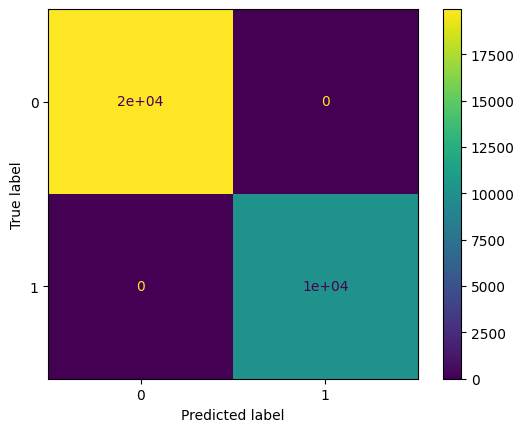

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.show()

In [22]:
prediction = model.predict(sample_ride)

probability = model.predict_proba(sample_ride)

print("Predicted outcome:",
      "Cancelled" if prediction[0] == 1 else "Completed")

print("Probability:", probability[0])

Predicted outcome: Completed
Probability: [1. 0.]


In [23]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [24]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [25]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


In [29]:
print(X.columns.tolist())

['year', 'month', 'day', 'weekday', 'Event', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Payment Method', 'hour_of_day']


In [30]:
print(df["is_cancelled"].value_counts())

is_cancelled
0    99666
1    51280
Name: count, dtype: int64


In [ ]:
print(df.groupby("is_cancelled")[["Avg VTAT", "Avg CTAT"]].mean())

              Avg VTAT   Avg CTAT
is_cancelled                     
0             8.505739  30.025583
1             8.817461  30.000000


In [ ]:
print("Training Accuracy:",
      model.score(X_train, y_train))

print("Testing Accuracy:",
      model.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier",
         RandomForestClassifier(
             n_estimators=100,
             random_state=42
         ))
    ]
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:",
      rf_accuracy)

Random Forest Accuracy: 1.0


In [34]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19934
           1       1.00      1.00      1.00     10256

    accuracy                           1.00     30190
   macro avg       1.00      1.00      1.00     30190
weighted avg       1.00      1.00      1.00     30190



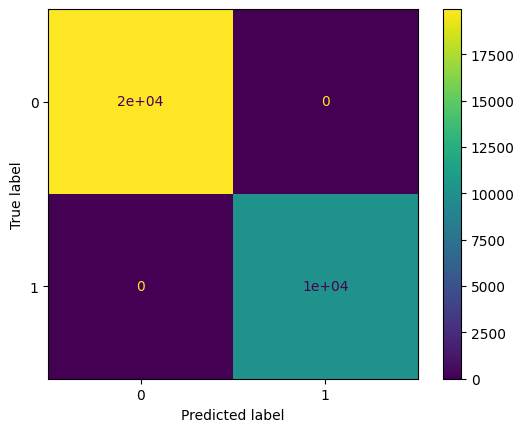

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.show()